In [ ]:
from models import UCM_Net, EGEUNet, GATv2Seg, IS_UNeXt, BGFFUNet
from utilities import inference_UNeXT, inference_EGE, inference_UCM, predict_graph, plot_comparison, inference_BGFF, count_params
import torch
import numpy as np
import cv2

EGE = EGEUNet()
UCM = UCM_Net(num_classes=1)
UNeXt = IS_UNeXt()
BGFF = BGFFUNet()
ours = GATv2Seg() # <----- PROPOSED

img_path =  "./ressources/resized_image.png"
mask_path_256 = "./ressources/resized_mask.png"
gt = cv2.imread(mask_path_256, cv2.IMREAD_GRAYSCALE)

print(f"EGEUNet  : {count_params(EGE)}")
print(f"UCM_Net  : {count_params(UCM)}")
print(f"IS_UNeXt : {count_params(UNeXt)}")

print(f"BGFFUNet : {count_params(BGFF)}")
print(f"GATv2Seg (PROPOSED) : {count_params(ours)}")

group_aggregation_bridge was used
gt deep supervision was used
EGEUNet  : 53374
UCM_Net  : 47436
IS_UNeXt : 917887
BGFFUNet : 24980
GATv2Seg (PROPOSED) : 13377


## uploading weights

### UNeXt

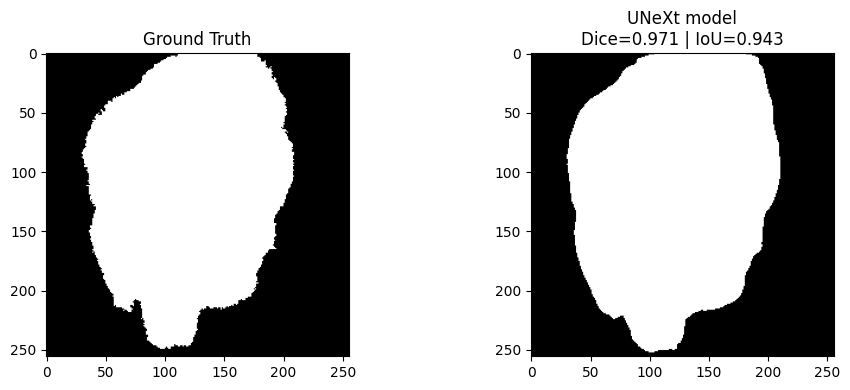

In [15]:
path_UNEXT = "./weights/best_lsUNeXt_ISIC18.pt"
UNeXt.load_state_dict(torch.load(path_UNEXT))

pred = inference_UNeXT(model=UNeXt, img_path=img_path)
pred = (pred.numpy() > 0.5).astype(np.uint8)

plot_comparison(gt, seg = pred, title2= 'UNeXt model') # Visualisation

## EGE

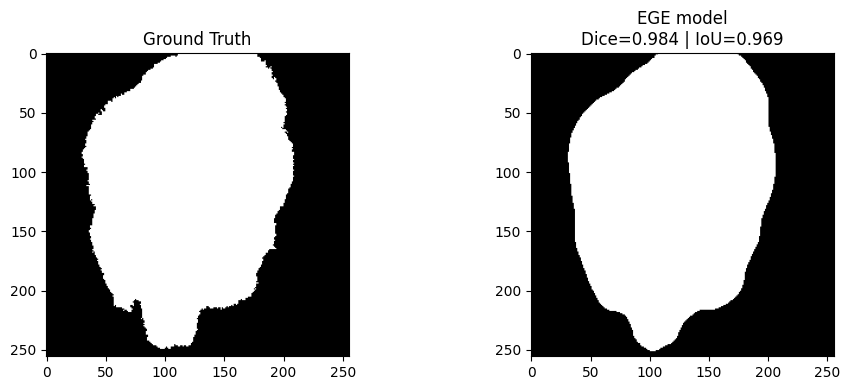

In [16]:
path_EGE = "./weights/best_EGEUNET_ISIC18.pth"

EGE.load_state_dict(torch.load(path_EGE))

pred = inference_EGE(model=EGE, img_path=img_path)

plot_comparison(gt, seg = pred, title2= 'EGE model') # Visualisation

## UCM

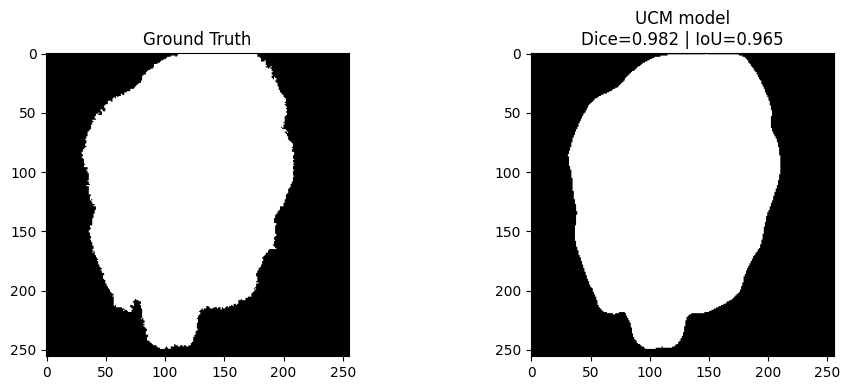

In [17]:
path_UCM = "./weights/best_UCMNET_ISIC18.pth"

UCM.load_state_dict(torch.load(path_UCM))

pred = inference_UCM(model=UCM, img_path=img_path)

plot_comparison(gt, seg = pred, title2= 'UCM model') # Visualisation

## BGFF

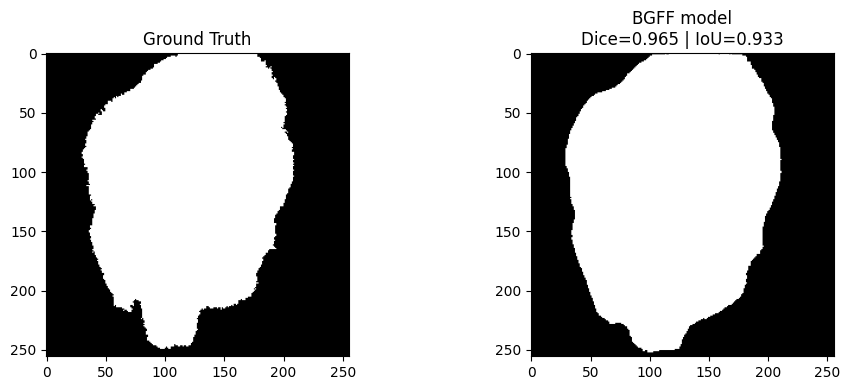

In [10]:
path_BGFF = "./weights/best_BGFF_ISIC18.pth" # Path for weights

BGFF.load_state_dict(torch.load(path_BGFF)) # Load weights

pred = inference_BGFF(model=BGFF, img_path=img_path) # Inference

plot_comparison(gt, seg = pred, title2= 'BGFF model') # Visualisation

# Ours

In [11]:
path_ours = "./weights/best_OURS_ISIC18.pth"     

checkpoint = torch.load(path_ours, weights_only=False)
ours.load_state_dict(checkpoint['model_state_dict'])

print("Same model used for both settings: trained on resized images and evaluated on both resized and original images")

Same model used for both settings: trained on resized images and evaluated on both resized and original images


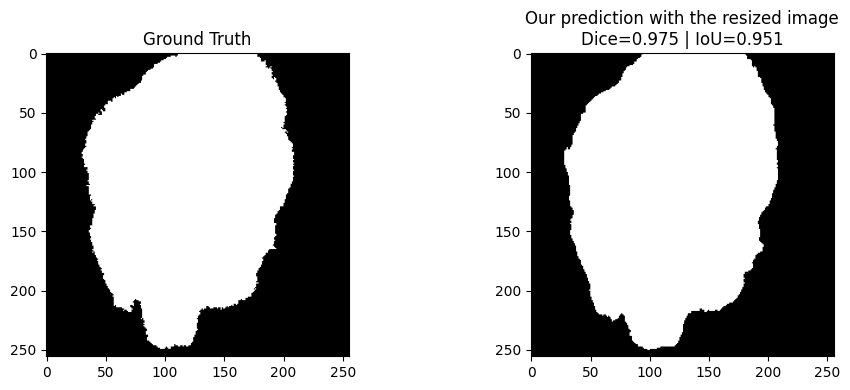

In [12]:
seg = predict_graph(ours, "./ressources/graph_resize.pt")

plot_comparison(gt, seg = seg, title2= 'Our prediction with the resized image')

# TEST ON THE ORIGINAL IMAGE with size : 2304 * 3072, Using the same PROPOSED model trained on images of 256*256

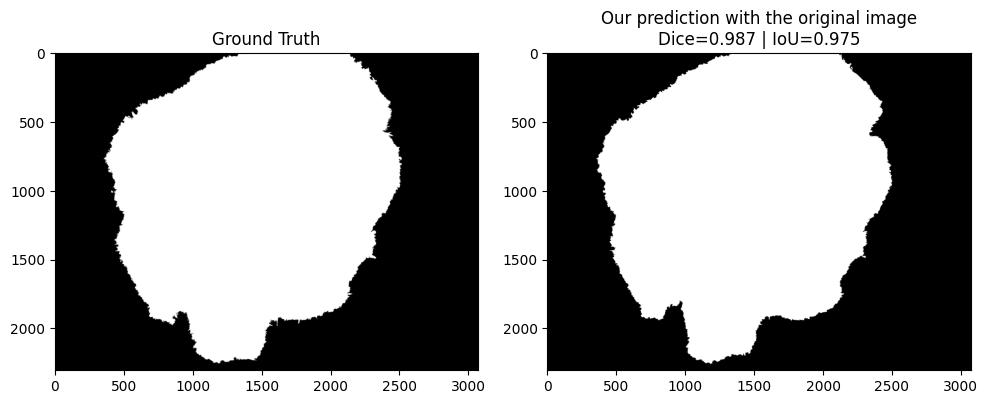

In [14]:
path = "./ressources/original_mask.png"

img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
seg = predict_graph(ours, "ressources/graph_original.pt", device="cpu")

plot_comparison(img, seg = seg, title2= 'Our prediction with the original image')